# Разметка learn-датасета моделью

Загружаем датасет `vsevolod-nv/aiconf-butterfly-learn-for-model-to-markup`, скачиваем изображения,
прогоняем VLM на всём наборе без расчёта метрик качества и публикуем результат в
`vsevolod-nv/aiconf-butterfly-learn`.


In [5]:
import base64
import json
import os
import re
from datetime import datetime, timezone
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd
import requests
from datasets import DatasetDict, load_dataset
from dotenv import load_dotenv
from huggingface_hub import HfApi
from IPython.display import display
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

load_dotenv()

SOY_TOKEN = os.getenv("SOY_TOKEN")

NOTEBOOK_DIR = Path(".")
DOWNLOADS_DIR = NOTEBOOK_DIR / "downloads"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DOWNLOADS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "vsevolod-nv/aiconf-butterfly-learn-for-model-to-markup"
TARGET_REPO_ID = "vsevolod-nv/aiconf-butterfly-learn"

MODEL_URL = "https://api.eliza.yandex.net/internal/qwen3-5-397b-a17b-fp8/v1/chat/completions"
MAX_ROWS = None
REQUEST_TIMEOUT = 310

RAW_RESULTS_PATH = OUTPUT_DIR / "results.jsonl"
CSV_RESULTS_PATH = OUTPUT_DIR / "results.csv"

PROMPT = """
Ты — модель для разметки изображений. Твоя задача: по входной картинке найти бабочку, если она есть, и вернуть координаты прямоугольника.

Правила разметки:
1. Выделяй только бабочек.
2. Если на изображении нет бабочки, верни пустой ответ:
{}
3. Прямоугольник должен плотно охватывать всю видимую бабочку:
   - включай крылья,
   - включай усики,
   - включай лапки,
   - не обрезай части тела,
   - лучше сделать рамку чуть больше, чем чуть меньше.
4. Если бабочка частично скрыта, выделяй только видимую часть.
5. Не выделяй:
   - тень бабочки,
   - фон,
   - листья, цветы, ветки, кору и другие объекты,
   - других насекомых, если это не бабочка.
6. Если фон сложный, пестрый, бабочка маскируется или почти сливается с окружением — все равно постарайся найти и выделить ее.
7. Если в кадре несколько бабочек, верни прямоугольник для каждой бабочки отдельным объектом в массиве.
8. Координаты должны быть нормализованными числами от 0 до 1 относительно ширины и высоты изображения.
9. Формат полей:
   - "shape": всегда "rectangle"
   - "left": x-координата левого края
   - "top": y-координата верхнего края
   - "width": ширина прямоугольника
   - "height": высота прямоугольника

Формат ответа:
- Если бабочка одна:
{"shape":"rectangle","left":0.123,"top":0.456,"width":0.321,"height":0.222}

- Если бабочек несколько:
[
  {"shape":"rectangle","left":0.123,"top":0.456,"width":0.321,"height":0.222},
  {"shape":"rectangle","left":0.654,"top":0.111,"width":0.120,"height":0.180}
]

- Если бабочки нет:
{}

Требования к ответу:
- Возвращай только JSON.
- Без пояснений, без markdown, без комментариев.
- Не добавляй никаких полей кроме: shape, left, top, width, height.
- Все числа должны быть десятичными.

Сначала проанализируй изображение, потом верни результат.
{{image}}
""".strip()

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)

print("Dataset:", DATASET_NAME)
print("Target repo:", TARGET_REPO_ID)
print("Downloads dir:", DOWNLOADS_DIR.resolve())
print("Output dir:", OUTPUT_DIR.resolve())
print("MAX_ROWS:", MAX_ROWS)


Dataset: vsevolod-nv/aiconf-butterfly-learn-for-model-to-markup
Target repo: vsevolod-nv/aiconf-butterfly-learn
Downloads dir: /Users/eraserhead/arcadia/junk/eraserhead/aiconf/model-runs/downloads
Output dir: /Users/eraserhead/arcadia/junk/eraserhead/aiconf/model-runs/outputs
MAX_ROWS: None


In [6]:
hf = load_dataset(DATASET_NAME)

if isinstance(hf, DatasetDict):
    split_names = list(hf.keys())
    frames = []
    for split_name in split_names:
        split_df = hf[split_name].to_pandas()
        split_df["dataset_split"] = split_name
        frames.append(split_df)
    data_df = pd.concat(frames, ignore_index=True)
else:
    split_names = ["train"]
    data_df = hf.to_pandas().copy()
    data_df["dataset_split"] = "train"

if "photo_url" in data_df.columns and "image" not in data_df.columns:
    data_df["image"] = data_df["photo_url"]

data_df["photo_id"] = data_df["photo_id"].astype(str)
data_df = data_df.dropna(subset=["photo_id", "image"]).drop_duplicates(subset=["photo_id"]).reset_index(drop=True)

if MAX_ROWS is not None:
    data_df = data_df.head(MAX_ROWS).copy()

print("Splits:", split_names)
print("Rows:", len(data_df))
display(data_df.head())


Splits: ['train']
Rows: 1000


,photo_id,image,entity,hard,photo_url,taxon,source_split,selection_group,target_label,needs_bbox_markup,dataset_split
0,624779576,https://inaturalist-open-data.s3.amazonaws.com/photos/624779576/original.jpg,bee,False,https://inaturalist-open-data.s3.amazonaws.com/photos/624779576/original.jpg,bee,train,negative,negative,False,train
1,624274153,https://inaturalist-open-data.s3.amazonaws.com/photos/624274153/original.jpg,beetle,False,https://inaturalist-open-data.s3.amazonaws.com/photos/624274153/original.jpg,beetle,train,negative,negative,False,train
2,624469142,https://inaturalist-open-data.s3.amazonaws.com/photos/624469142/original.jpg,beetle,True,https://inaturalist-open-data.s3.amazonaws.com/photos/624469142/original.jpg,beetle,train,negative,negative,False,train
3,624549626,https://inaturalist-open-data.s3.amazonaws.com/photos/624549626/original.jpg,beetle,False,https://inaturalist-open-data.s3.amazonaws.com/photos/624549626/original.jpg,beetle,train,negative,negative,False,train
4,620141299,https://inaturalist-open-data.s3.amazonaws.com/photos/620141299/original.jpg,butterfly,False,https://inaturalist-open-data.s3.amazonaws.com/photos/620141299/original.jpg,butterfly,train,positive,butterfly,True,train


In [7]:
def image_filename(row) -> str:
    image_url = str(row["image"])
    suffix = Path(urlparse(image_url).path).suffix or ".jpg"
    return f"{row['photo_id']}{suffix}"


def download_image(image_url: str, target_path: Path) -> Path:
    if not target_path.exists():
        response = requests.get(image_url, timeout=120)
        response.raise_for_status()
        target_path.write_bytes(response.content)
    return target_path


data_df = data_df.copy()
local_paths = []
for row in tqdm(data_df.to_dict("records"), total=len(data_df), desc="download"):
    local_path = DOWNLOADS_DIR / image_filename(row)
    download_image(str(row["image"]), local_path)
    local_paths.append(str(local_path))

data_df["local_image"] = local_paths
display(data_df[["photo_id", "image", "local_image"]].head())


download:   0%|          | 0/1000 [00:00<?, ?it/s]

,photo_id,image,local_image
0,624779576,https://inaturalist-open-data.s3.amazonaws.com/photos/624779576/original.jpg,downloads/624779576.jpg
1,624274153,https://inaturalist-open-data.s3.amazonaws.com/photos/624274153/original.jpg,downloads/624274153.jpg
2,624469142,https://inaturalist-open-data.s3.amazonaws.com/photos/624469142/original.jpg,downloads/624469142.jpg
3,624549626,https://inaturalist-open-data.s3.amazonaws.com/photos/624549626/original.jpg,downloads/624549626.jpg
4,620141299,https://inaturalist-open-data.s3.amazonaws.com/photos/620141299/original.jpg,downloads/620141299.jpg


In [8]:
def encode_image_file(image_path: str) -> str:
    return base64.b64encode(Path(image_path).read_bytes()).decode("utf-8")


def ask_model_with_image(prompt: str, image_b64: str) -> dict:
    headers = {
        "Authorization": f"OAuth {SOY_TOKEN}",
        "Content-Type": "application/json",
    }

    prompt_parts = prompt.split("{{image}}")
    content = []

    if prompt_parts[0]:
        content.append({"type": "text", "text": prompt_parts[0]})

    content.append(
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{image_b64}"},
        }
    )

    for part in prompt_parts[1:]:
        if part:
            content.append({"type": "text", "text": part})

    payload = {
        "messages": [
            {
                "role": "user",
                "content": content,
            }
        ],
    }

    response = requests.post(
        url=MODEL_URL,
        json=payload,
        headers=headers,
        timeout=REQUEST_TIMEOUT,
        verify=False,
    )
    response.raise_for_status()
    return response.json()


def extract_text_response(response_json: dict) -> str:
    try:
        return response_json["response"]["choices"][0]["message"]["content"].strip()
    except Exception as exc:
        raise ValueError(
            "Не удалось извлечь текст ответа модели:\n"
            f"{exc}\n{json.dumps(response_json, ensure_ascii=False, indent=2)}"
        ) from exc


def extract_json_block(text: str):
    text = text.strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    md_match = re.search(r"```(?:json)?\s*(\{.*?\}|\[.*?\])\s*```", text, re.DOTALL)
    if md_match:
        return json.loads(md_match.group(1))

    obj_match = re.search(r"(\{.*\}|\[.*\])", text, re.DOTALL)
    if obj_match:
        return json.loads(obj_match.group(1))

    raise ValueError(f"Не удалось найти JSON в ответе модели:\n{text}")


def normalize_boxes(parsed):
    if parsed in ({}, None):
        return []
    if isinstance(parsed, dict):
        return [parsed]
    if isinstance(parsed, list):
        return parsed
    raise ValueError(f"Неожиданный формат ответа: {type(parsed)}")


def clamp_box(box: dict) -> dict:
    left = max(0.0, min(1.0, float(box["left"])))
    top = max(0.0, min(1.0, float(box["top"])))
    width = max(0.0, min(1.0 - left, float(box["width"])))
    height = max(0.0, min(1.0 - top, float(box["height"])))
    return {
        "shape": "rectangle",
        "left": left,
        "top": top,
        "width": width,
        "height": height,
    }


def draw_boxes(image: Image.Image, boxes, color="red"):
    image = image.copy().convert("RGB")
    draw = ImageDraw.Draw(image)
    width, height = image.size
    for box in boxes:
        box = clamp_box(box)
        x1 = box["left"] * width
        y1 = box["top"] * height
        x2 = (box["left"] + box["width"]) * width
        y2 = (box["top"] + box["height"]) * height
        draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
    return image


In [9]:
def load_existing_results(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_json(path, lines=True)


def append_result(path: Path, row: dict) -> None:
    with path.open("a", encoding="utf-8") as fh:
        fh.write(json.dumps(row, ensure_ascii=False) + "\n")


def predict_row(row: dict) -> dict:
    local_image = row["local_image"]

    try:
        image_b64 = encode_image_file(local_image)
        response_json = ask_model_with_image(PROMPT, image_b64)
        raw_text = extract_text_response(response_json)
        parsed = extract_json_block(raw_text)
        pred_boxes = [clamp_box(box) for box in normalize_boxes(parsed)]
        error = None
    except Exception as exc:
        raw_text = ""
        pred_boxes = []
        error = repr(exc)

    result = dict(row)
    result["bbox"] = pred_boxes
    result["model_url"] = MODEL_URL
    result["model_raw_response"] = raw_text
    result["model_error"] = error
    result["processed_at"] = datetime.now(timezone.utc).isoformat()
    return result


existing_results_df = load_existing_results(RAW_RESULTS_PATH)
processed_ids = set(existing_results_df.get("photo_id", pd.Series(dtype=str)).astype(str)) if not existing_results_df.empty else set()

print("Existing rows:", len(existing_results_df))
print("Already processed photo_id:", len(processed_ids))

pending_df = data_df.loc[~data_df["photo_id"].astype(str).isin(processed_ids)].copy()
print("Pending rows:", len(pending_df))

for row in tqdm(pending_df.to_dict("records"), total=len(pending_df), desc="inference"):
    result = predict_row(row)
    append_result(RAW_RESULTS_PATH, result)

results_df = load_existing_results(RAW_RESULTS_PATH).sort_values("photo_id").reset_index(drop=True)
results_df.to_csv(CSV_RESULTS_PATH, index=False)

print("Saved:", RAW_RESULTS_PATH.resolve())
print("Saved:", CSV_RESULTS_PATH.resolve())
display(results_df.head())


Existing rows: 0
Already processed photo_id: 0
Pending rows: 1000


inference:   0%|          | 0/1000 [00:00<?, ?it/s]

/Users/eraserhead/arcadia/junk/eraserhead/aiconf/aiconf/lib/python3.13/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.eliza.yandex.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/eraserhead/arcadia/junk/eraserhead/aiconf/aiconf/lib/python3.13/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.eliza.yandex.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
/Users/eraserhead/arcadia/junk/eraserhead/aiconf/aiconf/lib/python3.13/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.eliza.yandex.net'. Adding certificate verification is strongly advised. See: https://

Saved: /Users/eraserhead/arcadia/junk/eraserhead/aiconf/model-runs/outputs/results.jsonl
Saved: /Users/eraserhead/arcadia/junk/eraserhead/aiconf/model-runs/outputs/results.csv


,photo_id,image,entity,hard,photo_url,taxon,source_split,selection_group,target_label,needs_bbox_markup,dataset_split,local_image,bbox,model_url,model_raw_response,model_error,processed_at
0,517347728,https://inaturalist-open-data.s3.amazonaws.com/photos/517347728/original.jpg,shrub,False,https://inaturalist-open-data.s3.amazonaws.com/photos/517347728/original.jpg,shrub,train,negative,negative,False,train,downloads/517347728.jpg,[],https://api.eliza.yandex.net/internal/qwen3-5-397b-a17b-fp8/v1/chat/completions,{},NaN,2026-04-20 03:33:53.049116+00:00
1,517347759,https://inaturalist-open-data.s3.amazonaws.com/photos/517347759/original.jpg,shrub,True,https://inaturalist-open-data.s3.amazonaws.com/photos/517347759/original.jpg,shrub,train,negative,negative,False,train,downloads/517347759.jpg,[],https://api.eliza.yandex.net/internal/qwen3-5-397b-a17b-fp8/v1/chat/completions,{},NaN,2026-04-20 03:14:36.125230+00:00
2,517347998,https://inaturalist-open-data.s3.amazonaws.com/photos/517347998/original.jpg,shrub,True,https://inaturalist-open-data.s3.amazonaws.com/photos/517347998/original.jpg,shrub,train,negative,negative,False,train,downloads/517347998.jpg,[],https://api.eliza.yandex.net/internal/qwen3-5-397b-a17b-fp8/v1/chat/completions,{},NaN,2026-04-20 03:20:30.058314+00:00
3,519071656,https://inaturalist-open-data.s3.amazonaws.com/photos/519071656/original.jpg,shrub,False,https://inaturalist-open-data.s3.amazonaws.com/photos/519071656/original.jpg,shrub,train,negative,negative,False,train,downloads/519071656.jpg,[],https://api.eliza.yandex.net/internal/qwen3-5-397b-a17b-fp8/v1/chat/completions,{},NaN,2026-04-20 03:21:34.715153+00:00
4,519642423,https://inaturalist-open-data.s3.amazonaws.com/photos/519642423/original.jpg,shrub,False,https://inaturalist-open-data.s3.amazonaws.com/photos/519642423/original.jpg,shrub,train,negative,negative,False,train,downloads/519642423.jpg,[],https://api.eliza.yandex.net/internal/qwen3-5-397b-a17b-fp8/v1/chat/completions,{},NaN,2026-04-20 03:09:06.689767+00:00


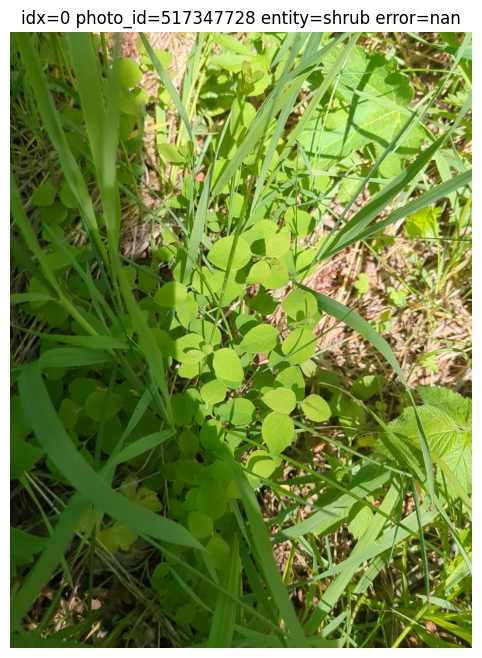

Image URL:
https://inaturalist-open-data.s3.amazonaws.com/photos/517347728/original.jpg

Pred:
[]

Raw response:
{}


In [10]:
def show_prediction(idx: int):
    row = results_df.iloc[idx]
    image = Image.open(row["local_image"]).convert("RGB")
    pred_image = draw_boxes(image, row["bbox"], color="red")

    plt.figure(figsize=(8, 8))
    plt.imshow(pred_image)
    plt.axis("off")
    plt.title(
        f"idx={idx} photo_id={row['photo_id']} entity={row.get('entity', '')} "
        f"error={row.get('model_error')!r}"
    )
    plt.show()

    print("Image URL:")
    print(row["image"])
    print("\nPred:")
    print(json.dumps(row["bbox"], ensure_ascii=False, indent=2))
    print("\nRaw response:")
    print(row["model_raw_response"])
    if pd.notna(row.get("model_error")):
        print("\nError:")
        print(row["model_error"])


show_prediction(0)


In [13]:
upload_df = results_df.copy().drop(columns=["local_image"], errors="ignore")

final_csv_path = OUTPUT_DIR / "qwen-learn-markup.csv"
upload_jsonl_path = OUTPUT_DIR / "data.jsonl"
upload_csv_path = OUTPUT_DIR / "results.csv"

upload_df.to_json(upload_jsonl_path, orient="records", lines=True, force_ascii=False)
upload_df.to_csv(upload_csv_path, index=False)
upload_df.to_csv(final_csv_path, index=False)

readme = f"""---
pretty_name: aiconf-butterfly-learn
task_categories:
- object-detection
tags:
- butterflies
- vlm
- object-detection
- dataset-generation
---

Model-assisted butterfly markup dataset.

Source dataset: `{DATASET_NAME}`
Generated at: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')}
Rows: {len(upload_df)}

Main columns:
{os.linesep.join(f"- `{column}`" for column in upload_df.columns)}
"""

api = HfApi()

with TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    data_path = tmp_path / "data.jsonl"
    csv_path = tmp_path / "qwen-learn-markup.csv"
    readme_path = tmp_path / "README.md"

    upload_df.to_json(data_path, orient="records", lines=True, force_ascii=False)
    upload_df.to_csv(csv_path, index=False)
    readme_path.write_text(readme, encoding="utf-8")

    api.create_repo(repo_id=TARGET_REPO_ID, repo_type="dataset", exist_ok=True)
    api.upload_folder(
        repo_id=TARGET_REPO_ID,
        repo_type="dataset",
        folder_path=str(tmp_path),
        commit_message="Upload learn dataset with model-generated markup",
    )

print("Saved locally:", upload_jsonl_path.resolve())
print("Saved locally:", upload_csv_path.resolve())
print("Saved locally:", final_csv_path.resolve())
print(f"Uploaded to: https://huggingface.co/datasets/{TARGET_REPO_ID}")
